<a href="https://colab.research.google.com/github/ligafinancefiap-svg/core-finance-lib/blob/main/03_Data_Lake_Analise_Quant_FIIs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Segmento - Bancos - Transformação de dados

Camada Gold

*   Métricas de Risco
*   Matriz Correlação
*   Relatório de Decisão

Mounted at /content/drive
✅ Camada GOLD finalizada para FIIS!
        Retorno Anual (%)  Volatilidade Anual (%)  Indice Sharpe
HGRU11               8.07                   12.10           0.67
KNRI11               8.03                   14.59           0.55
HGLG11               5.21                   10.60           0.49
XPLG11               4.52                   13.36           0.34
XPML11              49.72                  364.19           0.14


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


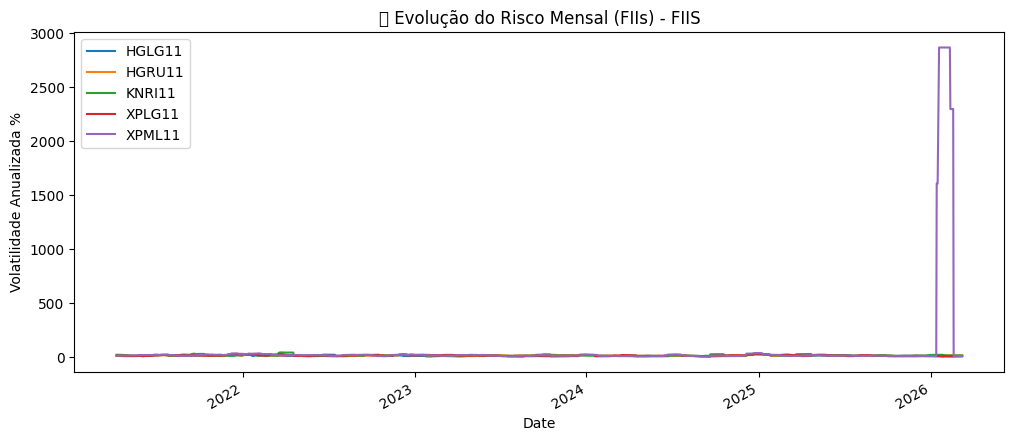

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive

drive.mount('/content/drive')
segmento = "fiis"
caminho_silver = f'/content/drive/MyDrive/DATA_LAKE/02_Silver/b3_{segmento}_limpo.csv'
caminho_gold_fixo = f'/content/drive/MyDrive/DATA_LAKE/03_Gold/b3_{segmento}_analise.csv'
caminho_gold_mensal = f'/content/drive/MyDrive/DATA_LAKE/03_Gold/b3_{segmento}_retorno_mensal.csv'

# 1. Cálculos Quant
df = pd.read_csv(caminho_silver, index_col=0, parse_dates=True)
log_retornos = np.log(df / df.shift(1)).dropna()

# Métricas Anualizadas
ret_anual = log_retornos.mean() * 252
vol_anual = log_retornos.std() * np.sqrt(252)
sharpe = ret_anual / vol_anual

# 2. Tabela Gold Executiva
df_gold = pd.DataFrame({
    'Retorno Anual (%)': (ret_anual * 100).round(2),
    'Volatilidade Anual (%)': (vol_anual * 100).round(2),
    'Indice Sharpe': sharpe.round(2)
}).sort_values(by='Indice Sharpe', ascending=False)

# 3. Visão Mensal para Projeções
retorno_mensal = log_retornos.resample('ME').sum()

# 4. Salvamento e Visualização
df_gold.to_csv(caminho_gold_fixo)
retorno_mensal.to_csv(caminho_gold_mensal)

print(f"✅ Camada GOLD finalizada para {segmento.upper()}!")
print(df_gold)

# Gráfico de Volatilidade Móvel (Monitorando o risco dos ativos de renda imobiliária)
(log_retornos.rolling(window=21).std() * np.sqrt(252) * 100).plot(figsize=(12,5))
plt.title(f"📊 Evolução do Risco Mensal (FIIs) - {segmento.upper()}")
plt.ylabel("Volatilidade Anualizada %")
plt.show()